In [1]:
!pip install opendatasets

In [2]:
import os
import opendatasets as od
od.download("https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset")


Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: sudiponmakal
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset


100%|██████████| 157M/157M [00:00<00:00, 1.47GB/s]

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.mixed_precision import set_global_policy

In [4]:
set_global_policy("mixed_float16")  # FP16 for speed
IMG_SIZE = (192, 192)
BATCH_SIZE = 32
NUM_CLASSES = 4
EPOCHS = 40

In [5]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/brain-tumor-mri-dataset/Training",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    "/content/brain-tumor-mri-dataset/Testing",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


['glioma', 'meningioma', 'notumor', 'pituitary']


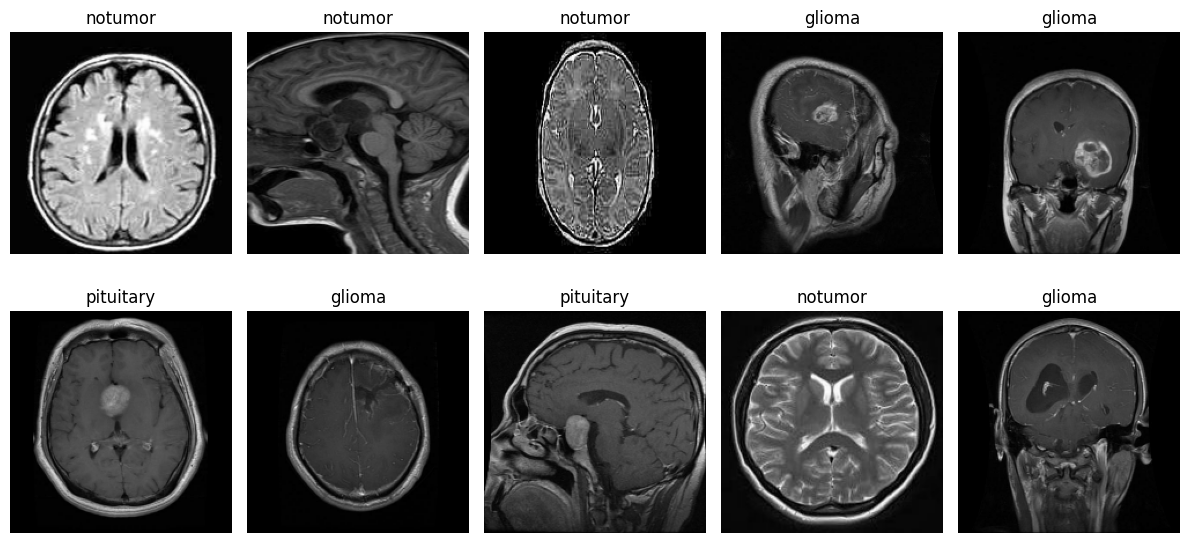

In [6]:
class_names = train_ds.class_names
print(class_names)
import matplotlib.pyplot as plt

class_names = train_ds.class_names

images, labels = next(iter(train_ds))

plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    label = class_names[tf.argmax(labels[i]).numpy()]
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
test_ds = test_ds.cache().prefetch(AUTOTUNE)

In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [9]:
from tensorflow.keras.applications import MobileNetV3Large

base_model = MobileNetV3Large(
    weights="imagenet",
    include_top=False,
    input_shape=IMG_SIZE + (3,)
)

base_model.trainable = False

inputs = layers.Input(shape=IMG_SIZE + (3,))
x = data_augmentation(inputs)

# MobileNetV3 preprocessing
x = tf.keras.applications.mobilenet_v3.preprocess_input(x)

x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)

outputs = layers.Dense(
    NUM_CLASSES,
    activation="softmax",
    dtype="float32"
)(x)

model = models.Model(inputs, outputs)

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:517: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [11]:
history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
)

Epoch 1/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 48s 61ms/step - accuracy: 0.5575 - loss: 1.1876 - val_accuracy: 0.7550 - val_loss: 0.6399
Epoch 2/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8209 - loss: 0.5027 - val_accuracy: 0.8006 - val_loss: 0.5702
Epoch 3/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8517 - loss: 0.4053 - val_accuracy: 0.8225 - val_loss: 0.5527
Epoch 4/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 43ms/step - accuracy: 0.8794 - loss: 0.3432 - val_accuracy: 0.8375 - val_loss: 0.5390
Epoch 5/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8898 - loss: 0.3018 - val_accuracy: 0.8500 - val_loss: 0.5169
Epoch 6/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - accuracy: 0.8947 - loss: 0.2913 - val_accuracy: 0.8544 - val_loss: 0.5082
Epoch 7/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.8977 - loss: 0.2661 - val_accuracy: 0.8606 - val_loss: 0.4891
Epoch 8/40
175/175 ━━━━━━━━━━━━━━━━━━━━ 7s 42ms/step - accuracy: 0.9119 - loss: 0.2456 - val_acc

In [12]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
history_finetune = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
)

Epoch 1/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 29s 65ms/step - accuracy: 0.8997 - loss: 0.2703 - val_accuracy: 0.8800 - val_loss: 0.4708
Epoch 2/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9228 - loss: 0.2074 - val_accuracy: 0.8594 - val_loss: 0.5778
Epoch 3/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - accuracy: 0.9388 - loss: 0.1736 - val_accuracy: 0.8700 - val_loss: 0.5496
Epoch 4/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9376 - loss: 0.1586 - val_accuracy: 0.8850 - val_loss: 0.5095
Epoch 5/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 55ms/step - accuracy: 0.9383 - loss: 0.1591 - val_accuracy: 0.8906 - val_loss: 0.4971
Epoch 6/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 9s 53ms/step - accuracy: 0.9484 - loss: 0.1432 - val_accuracy: 0.8981 - val_loss: 0.4772
Epoch 7/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - accuracy: 0.9525 - loss: 0.1257 - val_accuracy: 0.8931 - val_loss: 0.4849
Epoch 8/20
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 56ms/step - accuracy: 0.9514 - loss: 0.1197 - val

In [14]:
test_loss, test_acc = model.evaluate(test_ds)
print(f"Final Test Accuracy: {test_acc*100:.4f}%")

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.8190 - loss: 1.1173
Final Test Accuracy: 90.2500%


In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
y_pred = model.predict(test_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step


In [17]:
y_true = np.concatenate([y for x, y in test_ds], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

In [18]:
cm = confusion_matrix(y_true_classes, y_pred_classes)

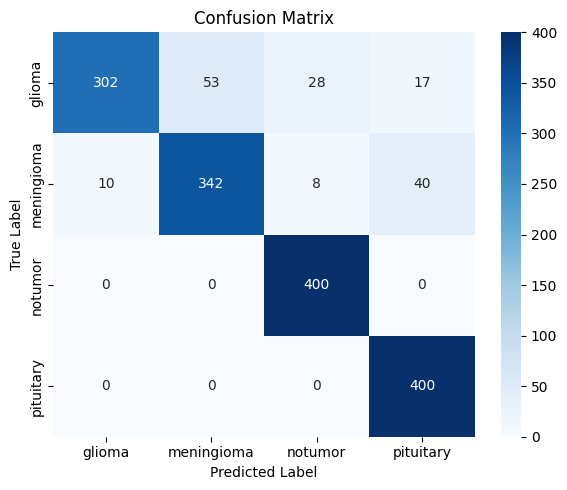

In [19]:
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

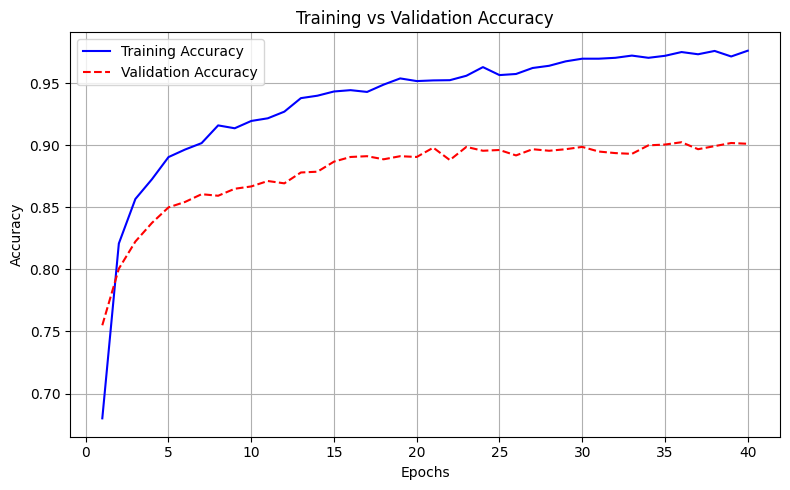

In [20]:
import matplotlib.pyplot as plt

# Get accuracy values
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_acc, 'b-', label='Training Accuracy')
plt.plot(epochs, val_acc, 'r--', label='Validation Accuracy')

plt.title('Training vs Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
